In [2]:
import copy
import json
import os
import pickle
import random
import socket
import subprocess
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import display

import robomimic
import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


hostname: mk-c
pid: 3349588
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-09d77f1f-8992-15cc-7b76-e48a47442fcd)


In [17]:
# Load automaton world model, diffusion policy, and environment

DP_CKPT_PATH = "/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth"
AUTOMATON_RUN_DIR = Path("/home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27")

assert Path(DP_CKPT_PATH).exists(), f"Policy checkpoint not found: {DP_CKPT_PATH}"
assert (AUTOMATON_RUN_DIR / "best_model.pt").exists(), f"Automaton checkpoint not found: {AUTOMATON_RUN_DIR / 'best_model.pt'}"

import importlib

try:
    import toy_squares.toy_squares_utils as ts_utils
except ModuleNotFoundError:
    import toy_squares_utils as ts_utils

ts_utils = importlib.reload(ts_utils)
load_automaton_model_for_eval = ts_utils.load_automaton_model_for_eval

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=False)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=False)
automaton_model, eval_stats, _, eval_meta = load_automaton_model_for_eval(
    model_or_run_path=str(AUTOMATON_RUN_DIR),
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)

print("Loaded policy and environment successfully.")
print("Loaded automaton world model from:", eval_meta["ckpt_path"])
print("Environment type:", type(env))


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.710221e+07
Created environment with name TouchCube
Action size is 2
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
Loaded policy and environment successfully.
Loaded automaton world model from: /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27/best_model.pt
Environment type: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


In [18]:
# Rollout helpers (no GIF export)

try:
    from toy_squares.toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup
except ModuleNotFoundError:
    from toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup

OUTPUT_ROOT = Path("/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance")


def _checkpoint_tag(path_str):
    return Path(path_str).name


def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _obs_low_level_snapshot(obs):
    snapshot = {}
    for key in ["states", "agent_pos"]:
        if key in obs:
            snapshot[key] = _to_numpy(obs[key]).copy()
    return snapshot


def _stack_or_object(values):
    values = list(values)
    if not values:
        return np.array([])
    try:
        return np.stack(values)
    except Exception:
        return np.array(values, dtype=object)


def run_rollout(policy, env, setup_fn, horizon=200):
    setup_state = _to_numpy(setup_fn(deterministic=False)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    total_reward = 0.0
    success = False
    steps = 0

    full_obs = [copy.deepcopy(obs)]
    low_level_obs = [_obs_low_level_snapshot(obs)]
    step_records = []

    for t in range(horizon):
        action = _to_numpy(policy(ob=obs)).copy()
        next_obs, reward, done, info = env.step(action)

        reward_value = float(reward)
        total_reward += reward_value
        steps = t + 1

        step_success = bool(info.get("success", False) or reward_value > 0)
        success = success or step_success

        step_records.append({
            "t": t,
            "action": action,
            "reward": reward_value,
            "done": bool(done),
            "success": step_success,
            "state": _obs_low_level_snapshot(obs),
        })

        full_obs.append(copy.deepcopy(next_obs))
        low_level_obs.append(_obs_low_level_snapshot(next_obs))
        obs = next_obs

        if done or success:
            break

    return {
        "success": float(success),
        "steps": steps,
        "return": total_reward,
        "setup_state": setup_state,
        "full_obs": full_obs,
        "low_level_obs": low_level_obs,
        "step_records": step_records,
    }


def _save_rollout_artifacts(run_dir, rollout):
    run_dir.mkdir(parents=True, exist_ok=True)

    with open(run_dir / "rollout_summary.json", "w", encoding="utf-8") as f:
        json.dump({"success": rollout["success"], "steps": rollout["steps"], "return": rollout["return"]}, f, indent=2)

    with open(run_dir / "full_obs.pkl", "wb") as f:
        pickle.dump(rollout["full_obs"], f)

    with open(run_dir / "step_records.pkl", "wb") as f:
        pickle.dump(rollout["step_records"], f)

    np.savez_compressed(
        run_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in rollout["low_level_obs"]]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in rollout["low_level_obs"]]),
    )
    np.save(run_dir / "setup_state.npy", rollout["setup_state"])


def evaluate_scenario(policy, env, setup_fn, scenario_name, n_rollouts=10, horizon=200):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    policy_path_tag = _checkpoint_tag(DP_CKPT_PATH)
    scenario_dir = OUTPUT_ROOT / policy_path_tag / f"n{n_rollouts}_{scenario_name}_h{horizon}_{timestamp}"
    scenario_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for rollout_idx in range(n_rollouts):
        rollout = run_rollout(policy, env, setup_fn, horizon=horizon)
        run_dir = scenario_dir / f"rollout_{rollout_idx:03d}"
        _save_rollout_artifacts(run_dir, rollout)
        records.append({
            "rollout_idx": rollout_idx,
            "success": rollout["success"],
            "steps": rollout["steps"],
            "return": rollout["return"],
            "run_dir": str(run_dir),
        })

    success_rate = float(np.mean([r["success"] for r in records])) if records else 0.0
    avg_steps = float(np.mean([r["steps"] for r in records])) if records else 0.0
    avg_return = float(np.mean([r["return"] for r in records])) if records else 0.0

    summary = {
        "scenario_name": scenario_name,
        "n_rollouts": n_rollouts,
        "horizon": horizon,
        "success_rate": success_rate,
        "avg_steps": avg_steps,
        "avg_return": avg_return,
        "policy_path": DP_CKPT_PATH,
        "automaton_model_path": str(AUTOMATON_RUN_DIR / "best_model.pt"),
        "scenario_dir": str(scenario_dir),
        "records": records,
    }

    with open(scenario_dir / "scenario_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    return summary

In [19]:
# Run Early and Late Decision scenarios (n=10)

env.reset()
early_results = evaluate_scenario(policy, env, early_decision_cube_setup, "early_decision", n_rollouts=10, horizon=200)
env.reset()
late_results = evaluate_scenario(policy, env, late_decision_cube_setup, "late_decision", n_rollouts=10, horizon=200)

print("Early Decision:", {k: v for k, v in early_results.items() if k != "records"})
print("Late Decision:", {k: v for k, v in late_results.items() if k != "records"})

ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!
Early Decision: {'scenario_name': 'early_decision', 'n_rollouts': 10, 'horizon': 200, 'success_rate': 1.0, 'avg_steps': 75.1, 'avg_return': 1.0, 'policy_path': '/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth', 'automaton_model_path': '/home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27/best_model.pt', 'scenario_dir': '/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/model_epoch_320_best_validation_0.005075077305082232.pth/n10_early_decision_h200_20260429_002706'}
Late Decision: {'scenario_name': 'late_decision', 'n

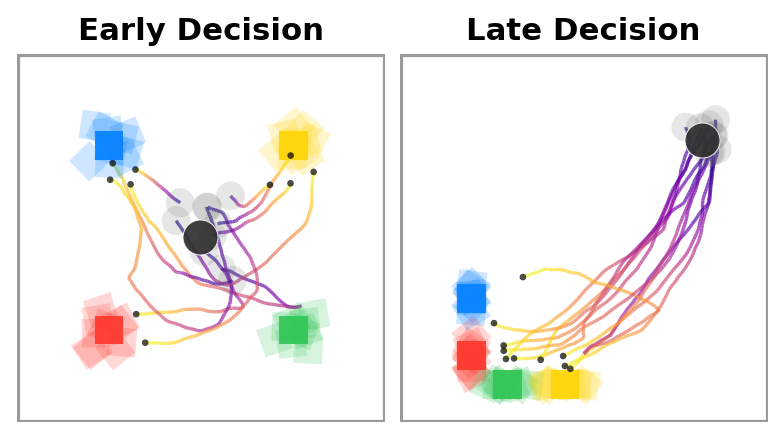

Saved overlay plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/model_epoch_320_best_validation_0.005075077305082232.pth/n10_late_decision_h200_20260429_002710/trajectory_overlay_20260429_002718.png


In [20]:
# Plot 10 early and 10 late rollouts

try:
    from toy_squares.toy_squares_utils import plot_early_late_rollouts_overlay
except ModuleNotFoundError:
    from toy_squares_utils import plot_early_late_rollouts_overlay

comparison_dir = Path(late_results["scenario_dir"])
fig, comparison_path = plot_early_late_rollouts_overlay(
    early_rollouts=early_results["records"],
    late_rollouts=late_results["records"],
    output_dir=comparison_dir,
    early_setup_fn=early_decision_cube_setup,
    late_setup_fn=late_decision_cube_setup,
)

display(fig)
plt.close(fig)
print(f"Saved overlay plot to {comparison_path}")